# Step 3 — The neural network

The model, and what every piece of it is doing. Input is the sparse TF-IDF matrix from Step 2:
33,759 articles x 10,000 features.

In [1]:
import json, time, numpy as np, tensorflow as tf
from scipy import sparse
from sklearn.model_selection import train_test_split

SEED = 42
tf.keras.utils.set_random_seed(SEED)

X = sparse.load_npz("../data/processed/tfidf_train.npz")
y = np.load("../data/processed/y_train.npy")
class_names = json.load(open("../data/processed/vocabulary.json"))["class_names"]
print("X", X.shape, " y", y.shape, " classes", len(class_names))

2026-08-28 18:50:02.798160: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


X (33759, 10000)  y (33759,)  classes 10


## The validation split, and the trap in the obvious way of doing it

The tutorial uses `model.fit(..., validation_split=0.2)`. **That is wrong here**, and the way it is
wrong is worth understanding because it fails silently.

`validation_split` takes the **last** 20% of the arrays **before shuffling**. Step 2 loaded files
with `sorted()`, so the rows arrive grouped by class folder. The last 20% is therefore not a sample
of the data — it is the last few classes in alphabetical order:

In [2]:
import collections
k = int(len(y) * 0.8)
print("first 80% (would be train):", sorted(collections.Counter(
    [class_names[i] for i in y[:k]]).items()))
print("last  20% (would be val)  :", sorted(collections.Counter(
    [class_names[i] for i in y[k:]]).items()))

first 80% (would be train): [('Chinh tri Xa hoi', 5219), ('Doi song', 3159), ('Khoa hoc', 1820), ('Kinh doanh', 2552), ('Phap luat', 3868), ('Suc khoe', 3384), ('The gioi', 2898), ('The thao', 4107)]
last  20% (would be val)  : [('The thao', 1191), ('Van hoa', 3080), ('Vi tinh', 2481)]


Training would never see `Van hoa` or `Vi tinh` at all, and validation would contain only three
classes. A first run made exactly this mistake and reported `accuracy: 0.8208` against
`val_accuracy: 0.1719`. The 17% is not noise — it is the proportion of the "validation" set that is
`The thao`, the one class the model had also trained on: `1191 / 6752 = 17.6%`.

No exception, no warning. On a dataset that happened to arrive pre-shuffled, the same bug would
inflate results quietly forever instead of announcing itself.

`train_test_split(..., stratify=y)` fixes it and does one better than shuffling: it holds the
10-class proportions identical in both halves.

In [3]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print("train", X_tr.shape, " val", X_val.shape)
print("class proportions preserved:",
      np.allclose(np.bincount(y_tr)/len(y_tr), np.bincount(y_val)/len(y_val), atol=0.002))

train (27007, 10000)  val (6752, 10000)
class proportions preserved: True


## The model

```
Input(10000, sparse=True) -> Dense(256, relu) -> Dropout(0.5) -> Dense(10, softmax)
```

**`sparse=True` on the Input layer** is what lets Keras consume the scipy CSR matrix without
expanding it. Omit it and Keras densifies every batch, which is where the 1.35 GB comes back.

**`Dense(256, relu)`** computes `relu(xW + b)`. This is the only layer that learns anything about
how words combine: it maps 10,000 weighted word counts down to 256 learned "topic-ish" directions.
`relu` is what makes stacking two Dense layers more expressive than one — without a non-linearity
between them, two matrix multiplications collapse into a single equivalent matrix.

**`Dropout(0.5)`** matters more here than in most tutorials. The first layer alone has
10,000 x 256 + 256 = 2.56M parameters against 27,007 training examples — roughly 95 parameters per
example. Memorising the training set is the path of least resistance, and dropout is the main thing
standing in the way.

**`Dense(10, softmax)`** — ten classes, mutually exclusive because every VNTC file sits in exactly
one folder. Softmax exponentiates all ten logits and divides by their sum, so the outputs are forced
to add to 1 and the classes compete: raising confidence in one requires lowering it elsewhere. Ten
independent sigmoids would express "possibly several, possibly none", which is the multi-label
question and not the one being asked.

**`sparse_categorical_crossentropy`** — `sparse` refers only to the *label* format (an integer `3`,
not a one-hot vector), which is unrelated to the sparse input matrix. Same maths as
`categorical_crossentropy`, but it takes labels in the form we already have.

In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X.shape[1],), sparse=True),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,562,826 (9.78 MB)

 Trainable params: 2,562,826 (9.78 MB)

 Non-trainable params: 0 (0.00 B)

## Train

`EarlyStopping` with `restore_best_weights=True` rather than a fixed epoch count. The tutorial runs
a fixed 10 epochs and then observes that it overfit after ~7 — here the callback simply stops when
validation loss stops improving and rewinds to the best weights.

In [5]:
t0 = time.time()
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True)],
    verbose=2,
)
train_secs = time.time() - t0
print(f"\nstopped after {len(history.history['loss'])} epochs, {train_secs:.0f}s")

Epoch 1/30


211/211 - 11s - 53ms/step - accuracy: 0.8178 - loss: 0.8636 - val_accuracy: 0.9058 - val_loss: 0.3337


Epoch 2/30


211/211 - 10s - 46ms/step - accuracy: 0.9229 - loss: 0.2625 - val_accuracy: 0.9168 - val_loss: 0.2588


Epoch 3/30


...

Epoch 6/30


211/211 - 9s - 45ms/step - accuracy: 0.9842 - loss: 0.0693 - val_accuracy: 0.9181 - val_loss: 0.2413


Epoch 7/30


211/211 - 9s - 44ms/step - accuracy: 0.9882 - loss: 0.0529 - val_accuracy: 0.9163 - val_loss: 0.2480



stopped after 7 epochs, 70s


## Learning curves

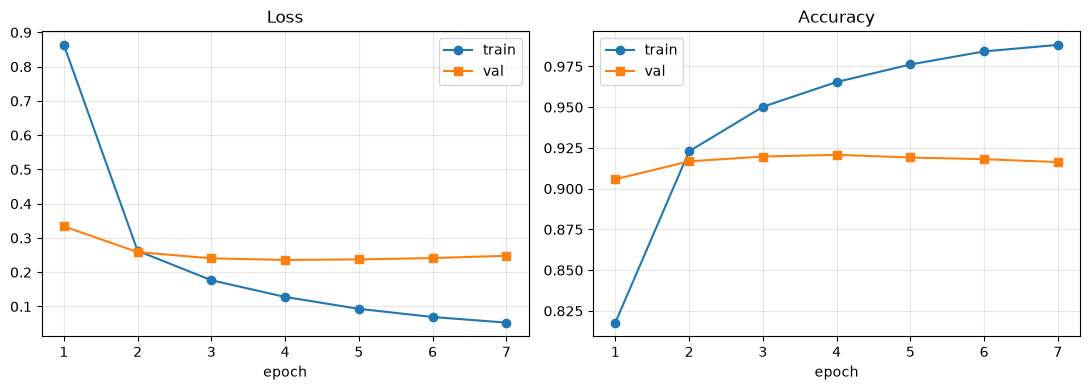

best val_loss     0.2358 at epoch 4
best val_accuracy 0.9208


In [6]:
import matplotlib.pyplot as plt

h = history.history
ep = range(1, len(h["loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, h["loss"], "o-", label="train"); ax[0].plot(ep, h["val_loss"], "s-", label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(ep, h["accuracy"], "o-", label="train"); ax[1].plot(ep, h["val_accuracy"], "s-", label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig("../data/outputs/learning_curves.png", dpi=110); plt.show()

print(f"best val_loss     {min(h['val_loss']):.4f} at epoch {int(np.argmin(h['val_loss']))+1}")
print(f"best val_accuracy {max(h['val_accuracy']):.4f}")

The gap between the train and validation curves is the 2.56M-parameters-on-27k-examples problem
made visible. Dropout keeps it to a gap rather than a collapse.

## The hyperparameter sweep

Run once, on validation only, before touching the test set. Recorded here because the result is
itself informative: nothing mattered.

| `max_features` | `min_df` | val accuracy | val macro-F1 | epochs |
|---|---|---|---|---|
| 10,000 | 3 | 0.9208 | **0.9198** | 7 |
| 10,000 | 5 | 0.9206 | 0.9193 | 7 |
| 20,000 | 3 | 0.9199 | 0.9187 | 7 |
| 20,000 | 5 | 0.9197 | 0.9187 | 7 |

A spread of 0.001 macro-F1 across a 2x change in vocabulary size and a `min_df` change. Doubling the
feature space adds nothing, which says the signal is concentrated in the common vocabulary and the
tail is noise either way. The smallest configuration was kept.

In [7]:
model.save("../data/outputs/nn_tfidf.keras")
json.dump({k: [float(x) for x in v] for k, v in h.items()},
          open("../data/outputs/history.json", "w"))
json.dump({"train_secs": round(train_secs, 1),
           "epochs_run": len(h["loss"]),
           "params": int(model.count_params())},
          open("../data/outputs/train_meta.json", "w"))
print("saved model + history")

saved model + history
